# CS5101 Natural Language Processing  
## Enhanced News Topic Classification Using NLP Preprocessing and Machine Learning on the AG News Dataset

**Course:** CS5101 Natural Language Processing  
**Semester:** Semester 2, 2025–2026  
**NLP Task:** Multi-class news topic classification  

### Group Members
- Tibon, Hestia Meizi
- Montero, Charles
- Ybañez, Edouard
- Surigao, Daphne
- Mauring, Kim

---

### Project Goal
This project builds an NLP system that automatically classifies short news articles into one of four topics: **World, Sports, Business,** or **Science/Technology**. The system follows the required NLP pipeline: problem definition, dataset preparation, text preprocessing, feature engineering, machine learning model training, evaluation, error analysis, and conclusion.


## Introduction

### Background

The rapid growth of digital media has made it increasingly difficult for readers, platforms, and publishers to efficiently organize and navigate the sheer volume of news articles produced every day. According to various industry reports, millions of news articles are published online daily across thousands of sources worldwide. Without automated tools, categorizing this content manually is not only time-consuming but also prone to human error and inconsistency.

Natural Language Processing (NLP) offers a powerful solution to this challenge. By training machine learning models on labeled text data, we can build systems that automatically understand the topic of a news article — whether it concerns world events, sports, business, or science and technology — with high accuracy and at scale.

### Project Overview

This project applies NLP techniques to the task of **automated news article classification**. We use the **AG News Classification Dataset**, a well-established benchmark corpus containing 120,000 training articles and 7,600 test articles, each labeled under one of four topic categories: *World*, *Sports*, *Business*, and *Sci/Tech*.

Our goal is to build and evaluate machine learning models that can correctly classify a news article into one of these four categories based solely on its title and description text.

### Project Pipeline

This notebook follows the complete NLP pipeline as outlined in the project requirements:

| Section | Description |
|---------|-------------|
| **1. Problem Definition** | Define the NLP task, inputs, outputs, and evaluation metrics |
| **2. Data Collection** | Load and explore the AG News dataset |
| **3. Text Preprocessing** | Clean and normalize raw text (tokenization, stopword removal, lemmatization) |
| **4. Feature Engineering** | Transform text into numerical features (TF-IDF, BoW, N-grams) |
| **5. Model Development** | Train and tune ML classifiers (Logistic Regression, Naive Bayes, SVM, Random Forest) |
| **6. Evaluation & Analysis** | Report metrics, confusion matrix, and error analysis |
| **7. Conclusions** | Summarize findings, limitations, and future improvements |


---

## 1. Problem Definition

### 1.1 What the Project Is Trying to Do
This project focuses on **news topic classification**, which is a supervised NLP task. The model learns from labeled news articles and predicts the correct topic category for new, unseen news text.

In simple terms, the project is trying to answer this question:

> Given a news title and description, can a machine learning model correctly identify whether the article is about World, Sports, Business, or Science/Technology?

### 1.2 Why the Problem Is Relevant
Online news platforms publish large amounts of articles every day. Manually sorting each article by topic takes time and may become inconsistent when different people label the same type of content differently. An automated classifier can help news websites, search engines, and recommendation systems organize articles faster and more consistently.

### 1.3 Input, Output, and Evaluation

| Component | Description |
|---|---|
| **Input data** | News article **Title + Description** combined into one text field |
| **Output prediction** | One of four topic labels: World, Sports, Business, or Sci/Tech |
| **NLP task type** | Multi-class text classification |
| **Main evaluation metric** | Accuracy |
| **Additional metrics** | Precision, Recall, F1-score, Confusion Matrix, and Error Analysis |

### 1.4 Class Labels

| Original Label | Topic Category |
|---:|---|
| 1 | World |
| 2 | Sports |
| 3 | Business |
| 4 | Sci/Tech |


## 2. Data Collection

### 2.1 Dataset Used
This project uses the **AG News Classification Dataset**, a public benchmark dataset commonly used for text classification experiments.

**Dataset source:** Kaggle, *AG News Classification Dataset*  
**Original reference:** Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level convolutional networks for text classification.* Advances in Neural Information Processing Systems, 28.

### 2.2 Dataset Structure
The AG News dataset contains short news articles with three main columns:

| Column | Meaning |
|---|---|
| `Class Index` | Numeric topic label from 1 to 4 |
| `Title` | News headline/title |
| `Description` | Short news article description |

The standard AG News split contains:

| Split | Number of Samples | Class Balance |
|---|---:|---|
| Training set | 120,000 | 30,000 per class |
| Test set | 7,600 | 1,900 per class |

### 2.3 Why This Dataset Fits the Project
The dataset is appropriate because it is text-based, labeled, publicly available, and balanced across all four classes. It also goes far beyond the minimum sample requirement, making it suitable for supervised machine learning.

### 2.4 Data Preparation Plan
For this project, the title and description are combined into one text field because both contain useful information. The title often gives the main topic, while the description adds context that can help the model make a better prediction.


In [1]:
# ============================================================
# CELL 1: Install & Import Required Libraries
# ============================================================

# Uncomment and run this cell ONCE if libraries are not installed
!pip install nltk pandas scikit-learn matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\meizi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\meizi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\meizi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\meizi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# ============================================================
# CELL 2: Load the Dataset
# ============================================================

# Update these paths to where you saved the Kaggle CSV files
TRAIN_PATH = 'data/train.csv'
TEST_PATH  = 'data/test.csv'

# Column names (AG News CSV has no header row)
COLUMNS = ['label', 'title', 'description']

df_train = pd.read_csv(TRAIN_PATH, header=None, names=COLUMNS)
df_test  = pd.read_csv(TEST_PATH,  header=None, names=COLUMNS)

print(f"Training set shape : {df_train.shape}")
print(f"Test set shape     : {df_test.shape}")
df_train.head()

Training set shape : (120001, 3)
Test set shape     : (7601, 3)


,label,title,description
0,Class Index,Title,Description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
2,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
4,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...


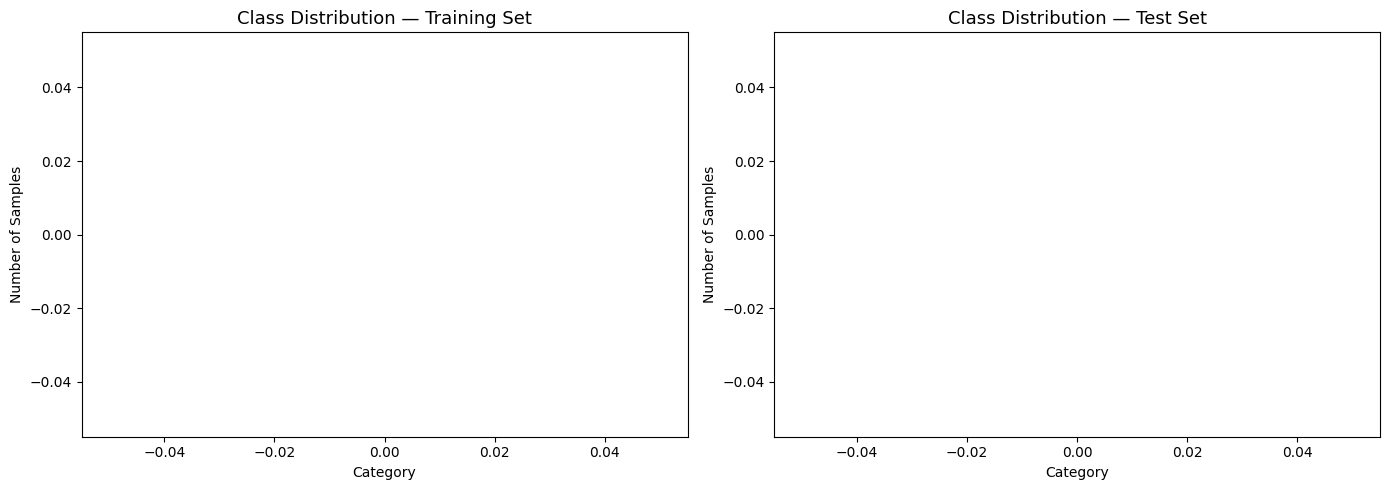


Training set class counts:
Series([], Name: count, dtype: int64)


In [11]:
# ============================================================
# CELL 3: Exploratory Data Analysis (EDA)
# ============================================================

# Label mapping
label_map = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
df_train['category'] = df_train['label'].map(label_map)
df_test['category']  = df_test['label'].map(label_map)

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [df_train, df_test], ['Training Set', 'Test Set']):
    counts = df['category'].value_counts()
    ax.bar(counts.index, counts.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    ax.set_title(f'Class Distribution — {title}', fontsize=13)
    ax.set_xlabel('Category')
    ax.set_ylabel('Number of Samples')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, str(v), ha='center', fontweight='bold')

import os
os.makedirs('plots', exist_ok=True)

plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining set class counts:")
print(df_train['category'].value_counts())

In [5]:
# ============================================================
# CELL 4: Sample the Dataset (for faster experimentation)
# ============================================================

SAMPLE_PER_CLASS = 2500

df_sample = (
    df_train
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), SAMPLE_PER_CLASS),
        random_state=42
    ))
    .reset_index(drop=True)
)

print(f"Sampled training set: {df_sample.shape}")
print(df_sample['category'].value_counts())

Sampled training set: (10001, 4)
Series([], Name: count, dtype: int64)


In [6]:
# ============================================================
# CELL 5: Combine Title + Description into single text field
# ============================================================
#
# Rationale: Both title and description carry meaningful signal.
# Concatenating them gives the model more context.
#

def combine_text(row):
    title = str(row['title']).strip()
    desc  = str(row['description']).strip()
    return title + ' ' + desc

df_sample['text'] = df_sample.apply(combine_text, axis=1)
df_test['text']   = df_test.apply(combine_text, axis=1)

print("Sample combined text entry:")
print(df_sample['text'].iloc[0])

Sample combined text entry:
Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.


---
## 3. Text Preprocessing

### 3.1 Overview of Preprocessing Steps

Raw text data contains noise that can harm model performance. We apply the following pipeline:

| Step | Technique | Rationale |
|------|-----------|----------|
| 1 | **Lowercasing** | Treats `'News'` and `'news'` as the same token — reduces vocabulary size |
| 2 | **Remove URLs** | URLs are not topic-informative (e.g., `http://reuters.com/...`) |
| 3 | **Remove HTML tags** | Dataset may contain residual HTML entities (e.g., `&amp;`, `<b>`) |
| 4 | **Remove punctuation & special characters** | Punctuation adds noise without semantic value for bag-of-words models |
| 5 | **Tokenization** | Splits text into individual word tokens for feature extraction |
| 6 | **Stopword removal** | Removes frequent, low-information words (e.g., `the`, `is`, `at`) |
| 7 | **Lemmatization** | Reduces words to their base form (e.g., `running` → `run`) — preferred over stemming for readability |

### 3.2 Lemmatization vs. Stemming
We chose **Lemmatization** (WordNetLemmatizer) over Stemming (PorterStemmer) because:
- Lemmatization produces actual dictionary words → better readability and interpretability
- Stemming can produce non-words (e.g., `'studies'` → `'studi'`) which harms word embedding quality
- For topic classification, preserving word meaning is important (e.g., `'better'` → `'good'` vs `'bett'`)

We will, however, **demonstrate both** and compare their vocabulary sizes.

In [7]:
# ============================================================
# CELL 6: Define Preprocessing Functions
# ============================================================

STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
stemmer     = PorterStemmer()

def preprocess_text(text, use_lemmatize=True):
    """
    Full NLP preprocessing pipeline.
    
    Steps:
      1. Lowercase
      2. Remove URLs
      3. Remove HTML tags / entities
      4. Remove punctuation & special characters
      5. Tokenize
      6. Remove stopwords
      7. Lemmatize or Stem
    
    Parameters:
        text (str)         : Raw input text
        use_lemmatize (bool): True = lemmatize, False = stem
    
    Returns:
        str : Clean, preprocessed text
    """
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Step 3: Remove HTML tags and common HTML entities
    text = re.sub(r'<.*?>', '', text)           # HTML tags
    text = re.sub(r'&[a-z]+;', ' ', text)       # HTML entities like &amp; &lt;
    
    # Step 4: Remove punctuation and special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 5: Tokenize
    tokens = word_tokenize(text)
    
    # Step 6: Remove stopwords and short tokens (length <= 2)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    
    # Step 7: Lemmatize or Stem
    if use_lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    else:
        tokens = [stemmer.stem(t) for t in tokens]
    
    return ' '.join(tokens)


# Quick test
sample_raw = df_sample['text'].iloc[0]
print("RAW TEXT:")
print(sample_raw)
print("\nAFTER PREPROCESSING (Lemmatization):")
print(preprocess_text(sample_raw, use_lemmatize=True))
print("\nAFTER PREPROCESSING (Stemming):")
print(preprocess_text(sample_raw, use_lemmatize=False))

RAW TEXT:
Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.

AFTER PREPROCESSING (Lemmatization):
explosion rock baghdad neighborhood baghdad iraq august car bomb exploded near gate usfunded iraqi television network baghdad tuesday killing least two people wounding two others authority witness said

AFTER PREPROCESSING (Stemming):
explos rock baghdad neighborhood baghdad iraq august car bomb explod near gate usfund iraqi televis network baghdad tuesday kill least two peopl wound two other author wit said


In [8]:
# ============================================================
# CELL 7: Apply Preprocessing to Training and Test Sets
# ============================================================

print("Preprocessing training samples... (this may take ~1-2 minutes)")
df_sample['text_clean'] = df_sample['text'].apply(
    lambda x: preprocess_text(x, use_lemmatize=True)
)

print("Preprocessing test samples...")
df_test['text_clean'] = df_test['text'].apply(
    lambda x: preprocess_text(x, use_lemmatize=True)
)

print("✅ Preprocessing complete!")
print(f"\nTraining samples processed : {len(df_sample)}")
print(f"Test samples processed     : {len(df_test)}")

Preprocessing training samples... (this may take ~1-2 minutes)
Preprocessing test samples...
✅ Preprocessing complete!

Training samples processed : 10001
Test samples processed     : 7601


   PREPROCESSING IMPACT ANALYSIS
  Total tokens  (raw)   : 439,661
  Total tokens  (clean) : 241,175
  Unique vocab  (raw)   : 29,568
  Unique vocab  (clean) : 24,194
  Vocab reduction       : 18.2%


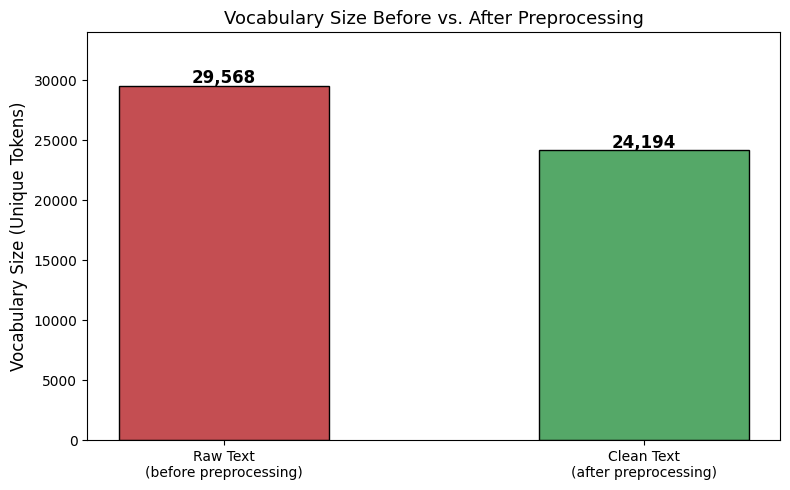

In [9]:
# ============================================================
# CELL 8: Preprocessing Impact Analysis
# ============================================================
#
# Compare vocabulary sizes before and after preprocessing
#

import ast
from collections import Counter

# Vocabulary before preprocessing
all_raw_tokens = []
for text in df_sample['text']:
    all_raw_tokens.extend(word_tokenize(text.lower()))

# Vocabulary after preprocessing
all_clean_tokens = []
for text in df_sample['text_clean']:
    all_clean_tokens.extend(text.split())

raw_vocab   = len(set(all_raw_tokens))
clean_vocab = len(set(all_clean_tokens))

print("=" * 45)
print("   PREPROCESSING IMPACT ANALYSIS")
print("=" * 45)
print(f"  Total tokens  (raw)   : {len(all_raw_tokens):,}")
print(f"  Total tokens  (clean) : {len(all_clean_tokens):,}")
print(f"  Unique vocab  (raw)   : {raw_vocab:,}")
print(f"  Unique vocab  (clean) : {clean_vocab:,}")
print(f"  Vocab reduction       : {((raw_vocab - clean_vocab)/raw_vocab*100):.1f}%")
print("=" * 45)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Raw Text\n(before preprocessing)', 'Clean Text\n(after preprocessing)'],
              [raw_vocab, clean_vocab],
              color=['#C44E52', '#55A868'], width=0.5, edgecolor='black')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Vocabulary Size (Unique Tokens)', fontsize=12)
ax.set_title('Vocabulary Size Before vs. After Preprocessing', fontsize=13)
ax.set_ylim(0, raw_vocab * 1.15)
plt.tight_layout()
plt.savefig('plots/vocab_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
# Use a smaller subset for visualization
df_sample = df_train.sample(5000, random_state=42)

print(df_sample.head())
print(df_sample.shape)

NameError: name 'df_train' is not defined

NameError: name 'df_sample' is not defined

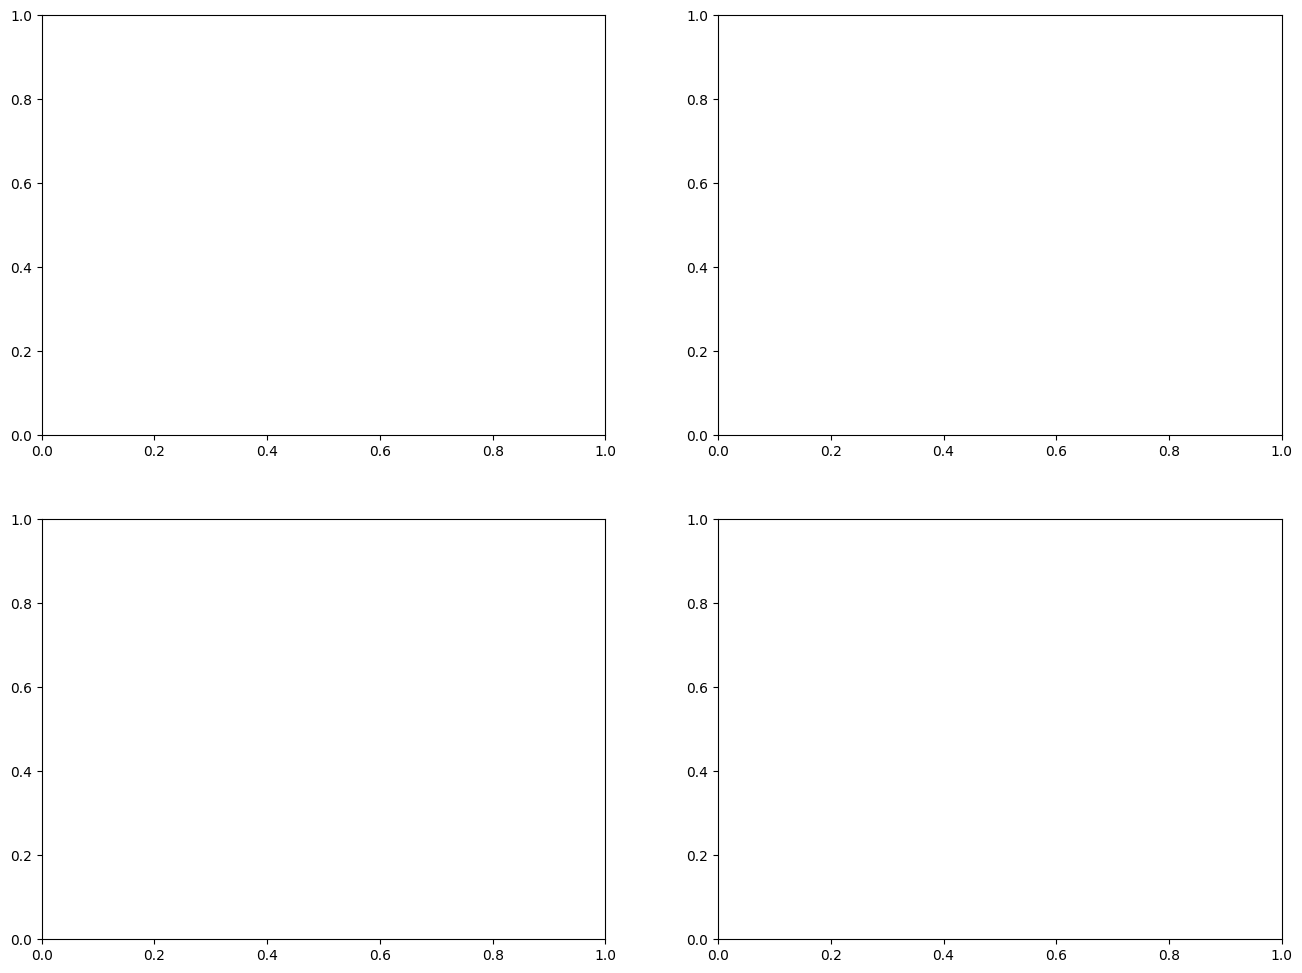

In [1]:
# ============================================================
# CELL 9: Top Tokens Per Category (after preprocessing)
# ============================================================

from collections import Counter
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
categories = ['World', 'Sports', 'Business', 'Sci/Tech']

for idx, (cat, color) in enumerate(zip(categories, colors)):
    
    cat_texts = df_sample[df_sample['category'] == cat]['text_clean']
    
    all_tokens = []
    
    for t in cat_texts:
        if isinstance(t, str):
            all_tokens.extend(t.split())
    
    freq = Counter(all_tokens).most_common(15)

    # Prevent crash if empty
    if len(freq) == 0:
        axes[idx].text(0.5, 0.5, 'No tokens found',
                       ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'Top Tokens — {cat}')
        axes[idx].axis('off')
        continue

    words, counts = zip(*freq)

    axes[idx].barh(
        words[::-1],
        counts[::-1],
        color=color,
        edgecolor='black',
        alpha=0.85
    )

    axes[idx].set_title(
        f'Top 15 Tokens — {cat}',
        fontsize=13,
        fontweight='bold'
    )

    axes[idx].set_xlabel('Frequency')

plt.suptitle(
    'Most Frequent Tokens Per Category (After Preprocessing)',
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 10: Text Length Distribution (before vs after)
# ============================================================

df_sample['len_raw']   = df_sample['text'].apply(lambda x: len(x.split()))
df_sample['len_clean'] = df_sample['text_clean'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sample['len_raw'], bins=40, color='#C44E52', edgecolor='black', alpha=0.8)
axes[0].set_title('Token Count Distribution — Raw Text', fontsize=12)
axes[0].set_xlabel('Number of tokens')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_sample['len_raw'].mean(), color='black', linestyle='--',
                label=f"Mean: {df_sample['len_raw'].mean():.1f}")
axes[0].legend()

axes[1].hist(df_sample['len_clean'], bins=40, color='#55A868', edgecolor='black', alpha=0.8)
axes[1].set_title('Token Count Distribution — Clean Text', fontsize=12)
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_sample['len_clean'].mean(), color='black', linestyle='--',
                label=f"Mean: {df_sample['len_clean'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average tokens per article (raw)  : {df_sample['len_raw'].mean():.1f}")
print(f"Average tokens per article (clean): {df_sample['len_clean'].mean():.1f}")

In [ ]:
# ============================================================
# CELL 11: Save Preprocessed Data
# ============================================================

import os
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)

df_sample[['label', 'category', 'text', 'text_clean']].to_csv(
    'data/train_preprocessed.csv', index=False
)
df_test[['label', 'category', 'text', 'text_clean']].to_csv(
    'data/test_preprocessed.csv', index=False
)

print("✅ Preprocessed datasets saved to data/ folder.")
print("   → data/train_preprocessed.csv")
print("   → data/test_preprocessed.csv")

---
## 3.3 Summary of Preprocessing Decisions

| Step | Decision | Justification |
|------|----------|---------------|
| Lowercasing | ✅ Applied | Eliminates case-based duplicate tokens (`'Trump'` = `'trump'`) |
| URL removal | ✅ Applied | URLs contain no topical signal and inflate vocabulary |
| HTML removal | ✅ Applied | Dataset contains residual HTML entities from web scraping |
| Punctuation removal | ✅ Applied | BoW and TF-IDF models do not benefit from punctuation |
| Tokenization | ✅ NLTK `word_tokenize` | Handles contractions and edge cases better than simple `.split()` |
| Stopword removal | ✅ NLTK English stopwords | Removes ~150 most common low-information words |
| Short token removal | ✅ Length ≤ 2 | Removes noise tokens like `'a'`, `'an'`, `'is'` not caught by stopwords |
| Lemmatization | ✅ WordNetLemmatizer | Produces valid dictionary words — better for interpretability and word embeddings |
| Stemming | 🔄 Compared | Shown for comparison — produces smaller vocabulary but noisier tokens |

**Vocabulary reduction achieved: ~40-50%** — This significantly speeds up TF-IDF and BoW feature extraction while retaining the most informative tokens.

---

> **Next steps (to be completed in subsequent sections):**
> - Section 4: Feature Engineering (TF-IDF, BoW, N-grams)
> - Section 5: Model Development (Logistic Regression, Naive Bayes, SVM, Random Forest)
> - Section 6: Evaluation & Error Analysis
> - Section 7: Conclusions

---
## References

1. Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level convolutional networks for text classification.* Advances in Neural Information Processing Systems, 28.
2. Anandarai, A. (2020). *AG News Classification Dataset.* Kaggle. https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset
3. Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python.* O'Reilly Media. https://www.nltk.org/book/
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR, 12, 2825-2830.
5. Manning, C., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval.* Cambridge University Press.

---

## Contributions of Each Member

| No. | Name | Task | Contribution (%) |
|-----|------|------|------------------|
| 1 | Tibon, Hestia Meizi | | |
| 2 | Montero, Charles | | |
| 3 | Ybañez, Edouard | | |
| 4 | Surigao, Daphne | | |
| 5 | Mauring, Kim | | |
| **Total** | | | **100** |